In [1]:
!pip install torchinfo

**Important Imports**

In [2]:
import os
import re
import cv2
import time
import glob
import random
import shutil
import platform
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict
from tabulate import tabulate
from tqdm import tqdm, notebook
from PIL import Image, ImageOps
import PIL
import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
from torchvision import transforms, datasets, models
from torchvision.datasets import ImageFolder
from torchvision.transforms import (
    ColorJitter, RandomRotation, RandomResizedCrop
)
from torchvision.transforms.functional import gaussian_blur

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from torchinfo import summary


**This section checks the current Kaggle runtime environment.It collects and displays:CPU model using the platform libraryTotal RAM (in GB) using psutilGPU name via the nvidia-smi command (if a GPU is available)**


In [3]:
cpu_info = platform.processor()

ram_info = psutil.virtual_memory()
total_ram_gb = ram_info.total / (1024 ** 3)

try:
    gpu_info = !nvidia-smi --query-gpu=gpu_name --format=csv
    gpu_name = gpu_info[1]
except:
    gpu_name = "No GPU available"

print("CPU:", cpu_info)
print("Total RAM (GB):", round(total_ram_gb, 2))
print("GPU:", gpu_name)

CPU: x86_64
Total RAM (GB): 31.35
GPU: Tesla P100-PCIE-16GB



**To ensure consistent and repeatable results across different runs, a fixed random seed is set here.This controls the randomness in:PyTorch CPU and GPU operations (torch.manual_seed, torch.cuda.manual_seed)NumPy and Python’s built-in random moduleUsing the same seed guarantees that data shuffling, weight initialization, and other random processes produce the same outputs each time the notebook is executed.**


In [4]:
import os

seed = 1
random.seed(seed)
np.random.seed(seed)
os.environ["PYTHONHASHSEED"] = str(seed)

torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



**This code organizes PM25Vision images by air-quality labels.It reads metadata.csv, maps PM2.5 bins to categories (Good, Moderate, Unhealthy, etc.), creates label folders, and copies images accordingly.Finally, it prints summary counts and skipped files — readying the dataset for training.**


In [5]:
import re
import shutil
import pandas as pd
from pathlib import Path


CSV_PATH = Path("/kaggle/input/pm25vision/train/metadata.csv")
IMG_DIR  = Path("/kaggle/input/pm25vision/train/images")
OUT_DIR  = Path("/kaggle/working/dataset")
OUT_DIR.mkdir(parents=True, exist_ok=True)

AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return None  

def bin_to_label(bin_val) -> str:
    """
    Accepts '0–50', '0-50', '0 — 50', etc.
    Extracts the LOWER numeric bound and maps to label.
    """
    s = str(bin_val).strip()
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    m = re.search(r"(\d+)", s)
    if not m:
        return None
    lo = int(m.group(1))
    return aqi_to_label(lo)


df = pd.read_csv(CSV_PATH)
assert "pm25_bin" in df.columns, f"Expected 'pm25_bin' column but found {df.columns}"

fname_col = "filename" if "filename" in df.columns else ("file" if "file" in df.columns else None)
if fname_col is None:
    raise ValueError(f"No image filename column found. Columns: {list(df.columns)}")

df["fname"] = df[fname_col].astype(str)
df["level"] = df["pm25_bin"].apply(bin_to_label)

df = df.dropna(subset=["level"])

print("Class counts:")
print(df["level"].value_counts(dropna=False))

for _, _, label in AQI_BINS:
    (OUT_DIR / label).mkdir(parents=True, exist_ok=True)

missing = 0
copied  = 0
valid_labels = {b[2] for b in AQI_BINS}

for _, row in df.iterrows():
    src = IMG_DIR / row["fname"]
    if not src.exists():
        missing += 1
        continue

    if row["level"] not in valid_labels:
        continue

    dst = OUT_DIR / row["level"] / src.name
    shutil.copy2(src, dst)
    copied += 1

print(f"✅ Done! Copied: {copied} | Missing files skipped: {missing}")
print(f"Output root: {OUT_DIR}")

Class counts:
level
Good                   1780
Moderate               1780
Unhealthy_Sensitive    1780
Unhealthy              1780
Very_Unhealthy          822
Hazardous               356
Name: count, dtype: int64
✅ Done! Copied: 8298 | Missing files skipped: 0
Output root: /kaggle/working/dataset



**This block organizes the test images into the same labeled structure as the training dataset.It reads metadata.csv, maps PM2.5 bins to air-quality categories, and copies each image into its respective label folder under /kaggle/working/dataset/.Duplicate files are checked and renamed if needed, while missing images are skipped.Finally, it prints a summary of copied, skipped, and renamed files.**


In [6]:
import re
import shutil
import pandas as pd
from pathlib import Path

TEST_CSV_PATH = Path("/kaggle/input/pm25vision/test/metadata.csv")
TEST_IMG_DIR  = Path("/kaggle/input/pm25vision/test/images")
OUT_TEST_DIR  = Path("/kaggle/working/dataset")
OUT_TEST_DIR.mkdir(parents=True, exist_ok=True)

AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str | None:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return None

def bin_to_label(bin_val) -> str | None:
    s = str(bin_val).strip()
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    m = re.search(r"(\d+)", s)
    if not m:
        return None
    lo = int(m.group(1))
    return aqi_to_label(lo)

df_t = pd.read_csv(TEST_CSV_PATH)
assert "pm25_bin" in df_t.columns, f"Expected 'pm25_bin' in TEST CSV, got: {df_t.columns}"

fname_col_t = "filename" if "filename" in df_t.columns else ("file" if "file" in df_t.columns else None)
if fname_col_t is None:
    raise ValueError(f"No image filename column in TEST CSV. Columns: {list(df_t.columns)}")

df_t["fname"] = df_t[fname_col_t].astype(str)
df_t["level"] = df_t["pm25_bin"].apply(bin_to_label)

missing, copied, skipped_same, renamed_dupe = 0, 0, 0, 0
valid_labels = {b[2] for b in AQI_BINS}

for _, r in df_t.iterrows():
    src = TEST_IMG_DIR / r["fname"]
    if not src.exists():
        missing += 1
        continue
    if r["level"] not in valid_labels:
        continue

    dest_dir = OUT_TEST_DIR / r["level"]        # <-- write into dataset_test
    dest_dir.mkdir(parents=True, exist_ok=True)

    dst = dest_dir / src.name
    if dst.exists():
        if os.path.getsize(dst) == os.path.getsize(src):
            skipped_same += 1
            continue
        dst = dest_dir / f"test__{src.name}"
        renamed_dupe += 1

    shutil.copy2(src, dst)
    copied += 1

print("✅ TEST copy complete.")
print(f"Copied: {copied} | Missing files: {missing} | Skipped exact-duplicates: {skipped_same} | Renamed (name clash): {renamed_dupe}")
print(f"Test output root: {OUT_TEST_DIR}")


✅ TEST copy complete.
Copied: 2905 | Missing files: 0 | Skipped exact-duplicates: 16 | Renamed (name clash): 0
Test output root: /kaggle/working/dataset



**This code counts the number of images in each air-quality class under /kaggle/working/dataset/.It prints per-class image totals and the overall dataset size — useful for confirming that all files were organized correctly.**


In [7]:
from pathlib import Path
import shutil

OUT_DIR = Path("/kaggle/working/dataset")


unknown_dir = OUT_DIR / "Unknown"
if unknown_dir.exists() and unknown_dir.is_dir():
    shutil.rmtree(unknown_dir)


class_counts = {}
for sub in OUT_DIR.iterdir():
    if sub.is_dir():
        class_counts[sub.name] = len(list(sub.glob("*")))

print(" Image count per class:\n")

for k, v in sorted(class_counts.items()):
    print(f"{k:20s}: {v}")

print("\nTotal images:", sum(class_counts.values()))

 Image count per class:

Good                : 2408
Hazardous           : 481
Moderate            : 2407
Unhealthy           : 2407
Unhealthy_Sensitive : 2393
Very_Unhealthy      : 1007

Total images: 11103



**This code scans the organized dataset under /kaggle/working/dataset/ and builds a DataFrame listing each image path and its label.It filters valid image formats (.jpg, .jpeg, .png), counts total samples per class, and defines a helper function to load images as RGB arrays.Useful for quick checks, visualization, or later data-loader creation.**


In [8]:
from pathlib import Path
from PIL import Image

BASE_DIR = Path("/kaggle/working/dataset")  
assert BASE_DIR.exists(), BASE_DIR

rows = []
for label_dir in sorted([p for p in BASE_DIR.iterdir() if p.is_dir()]):
    label = label_dir.name
    for p in label_dir.glob("*"):
        if p.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        rows.append({"path": str(p), "label": label})

df = pd.DataFrame(rows)
print("Total images indexed:", len(df))
print("Class balance:\n", df["label"].value_counts())

def load_rgb(path):
    with Image.open(path) as im:
        im = im.convert("RGB")
        return np.array(im)

df.head(20)

Total images indexed: 11103
Class balance:
 label
Good                   2408
Moderate               2407
Unhealthy              2407
Unhealthy_Sensitive    2393
Very_Unhealthy         1007
Hazardous               481
Name: count, dtype: int64


,path,label
0,/kaggle/working/dataset/Good/271583751360430.jpg,Good
1,/kaggle/working/dataset/Good/240907638878893.jpg,Good
2,/kaggle/working/dataset/Good/500343708069781.jpg,Good
3,/kaggle/working/dataset/Good/259856772488253.jpg,Good
4,/kaggle/working/dataset/Good/4218381994848162.jpg,Good
5,/kaggle/working/dataset/Good/507223953745546.jpg,Good
6,/kaggle/working/dataset/Good/2650202498607133.jpg,Good
7,/kaggle/working/dataset/Good/1265887737633556.jpg,Good
8,/kaggle/working/dataset/Good/1340324676842594.jpg,Good
9,/kaggle/working/dataset/Good/471550297443705.jpg,Good



**This code visualizes the number of images in each air-quality category using a Seaborn bar chart.It helps verify dataset balance and ensure all classes are properly represented before training.**


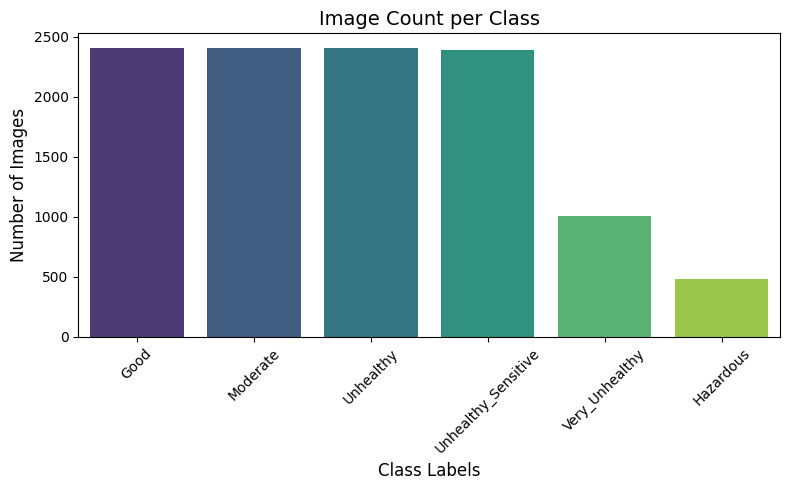

In [9]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df["label"].value_counts().index,
            y=df["label"].value_counts().values,
            palette="viridis")
plt.title("Image Count per Class", fontsize=14)
plt.xlabel("Class Labels", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**This code displays a small gallery showing two random sample images from each air-quality class.It helps visually verify the dataset and observe differences across categories such as Good, Moderate, and Unhealthy.Useful for quick quality checks and understanding visual variation before model training.**


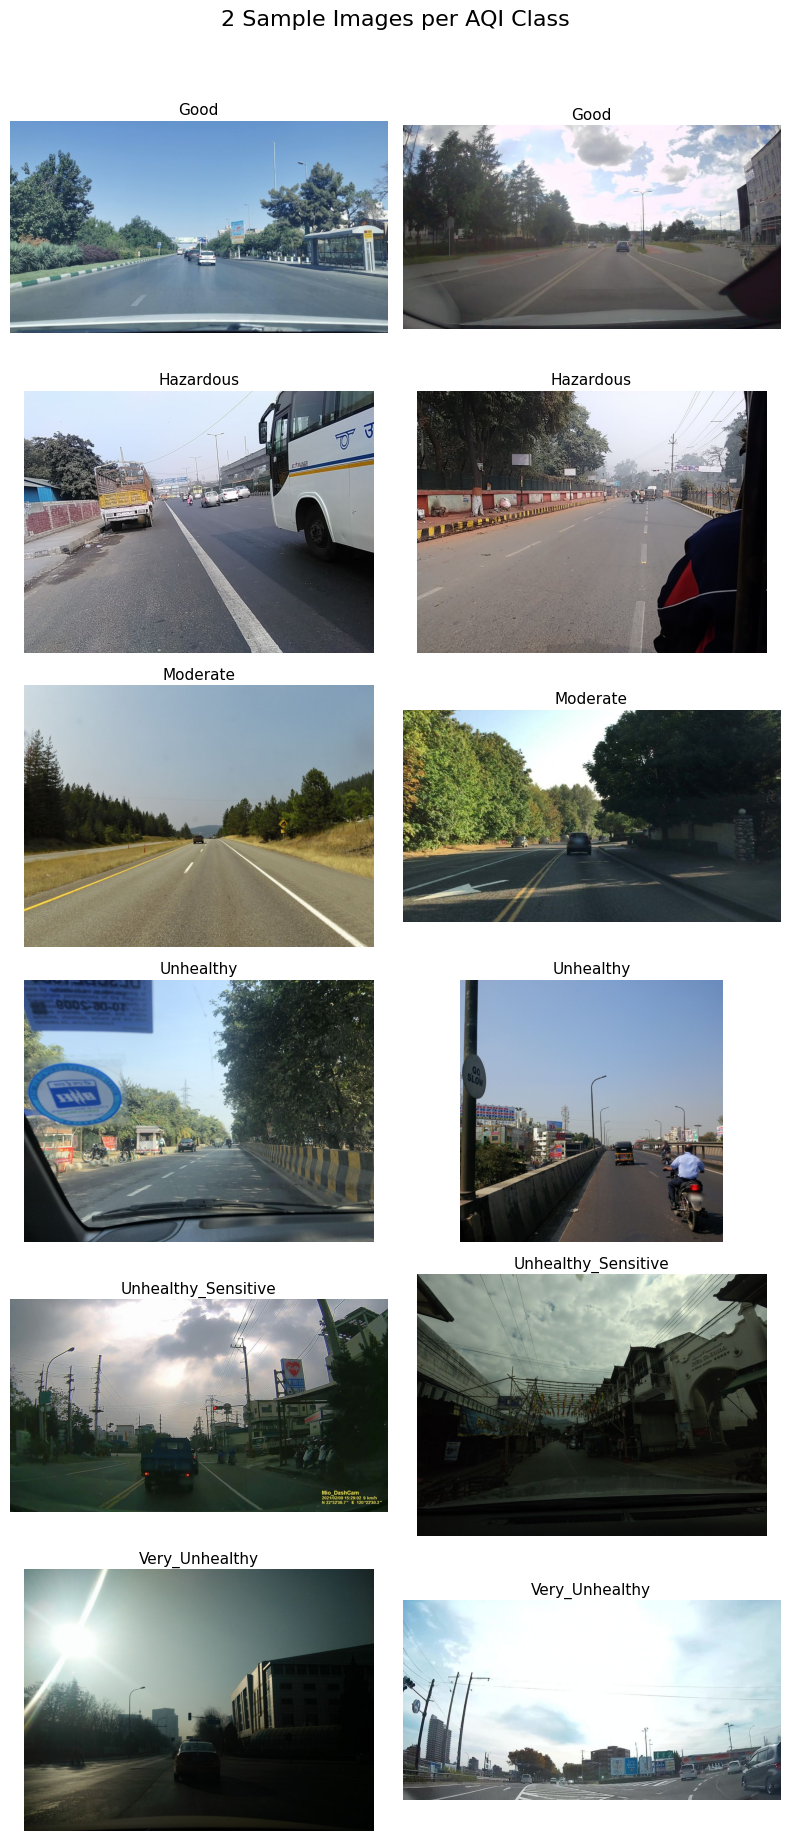

In [10]:
from PIL import Image

classes = sorted(df["label"].unique())

N_PER_CLASS = 2

plt.figure(figsize=(N_PER_CLASS * 4, len(classes) * 3))

for i, lbl in enumerate(classes):
    subset = df[df["label"] == lbl]["path"].tolist()
    sample_paths = random.sample(subset, min(N_PER_CLASS, len(subset)))
    
    for j, path in enumerate(sample_paths):
        idx = i * N_PER_CLASS + j + 1
        plt.subplot(len(classes), N_PER_CLASS, idx)
        
        img = Image.open(path)
        plt.imshow(img)
        plt.axis("off")
        
        plt.title(lbl, fontsize=11, pad=4)

plt.suptitle("2 Sample Images per AQI Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


**This block divides the dataset into train, validation, and test sets for multiple ratios (from 90:10 down to 10:90).Each split is stratified by class labels to keep class balance and uses a fixed random seed (42) for reproducibility.From the training portion, 10% is further used as validation.All splits are saved in dictionaries (SPLITS, FIXED_IDX) and a summary table shows image counts for every ratio**


In [11]:
from sklearn.model_selection import train_test_split
import pandas as pd
from pathlib import Path
import numpy as np
import os


OUT_DIR = Path("/kaggle/working/dataset")

rows = []
for class_dir in sorted([p for p in OUT_DIR.iterdir() if p.is_dir()]):
    label = class_dir.name
    for img_path in class_dir.glob("*"):
        if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        rows.append({"path": str(img_path), "label": label})

df = pd.DataFrame(rows)
print(f"✅ Found total {len(df)} images across {df['label'].nunique()} classes.")

RATIOS = [(90,10),(80,20),(70,30),(60,40),(50,50),(40,60),(30,70),(20,80),(10,90)]
RANDOM_STATE = 42


SPLITS = {}  
FIXED_IDX = {} 
all_idx = np.arange(len(df))
labels_all = df["label"].values


for tr, te in RATIOS:
    test_size = te / 100.0

    train_pool_idx, test_idx = train_test_split(
        all_idx,
        test_size=test_size,
        stratify=labels_all,
        random_state=RANDOM_STATE
    )
    FIXED_IDX[(tr, te)] = {
        "train_pool_idx": train_pool_idx,
        "test_idx": test_idx
    }

    train_pool_df = df.iloc[train_pool_idx].reset_index(drop=True)
    tr_local_idx, va_local_idx = train_test_split(
        np.arange(len(train_pool_df)),
        test_size=0.10,
        stratify=train_pool_df["label"].values,
        random_state=RANDOM_STATE
    )

    train_idx = train_pool_idx[tr_local_idx]
    valid_idx = train_pool_idx[va_local_idx]

    train_df = df.iloc[train_idx].reset_index(drop=True)
    valid_df = df.iloc[valid_idx].reset_index(drop=True)
    test_df  = df.iloc[test_idx].reset_index(drop=True)

    SPLITS[(tr, te)] = {
        "train_df": train_df,
        "valid_df": valid_df,
        "test_df":  test_df
    }


print("\n=== Split Summary (counts) ===")
for tr, te in RATIOS:
    s = SPLITS[(tr, te)]
    print(f"{tr}:{te} -> train={len(s['train_df'])}, val={len(s['valid_df'])}, test={len(s['test_df'])}")
print("-------------------------------------------")
print("Total images in dataset: ", len(df))

✅ Found total 11103 images across 6 classes.

=== Split Summary (counts) ===
90:10 -> train=8992, val=1000, test=1111
80:20 -> train=7993, val=889, test=2221
70:30 -> train=6994, val=778, test=3331
60:40 -> train=5994, val=667, test=4442
50:50 -> train=4995, val=556, test=5552
40:60 -> train=3996, val=445, test=6662
30:70 -> train=2997, val=333, test=7773
20:80 -> train=1998, val=222, test=8883
10:90 -> train=999, val=111, test=9993
-------------------------------------------
Total images in dataset:  11103



**This block prints class-wise image counts for train, validation, and test sets at each ratio using the tabulate library.It helps verify that all splits remain balanced across classes and that no samples are missing.**


In [12]:
from tabulate import tabulate

for tr, te in RATIOS:
    s = SPLITS[(tr, te)]
    train_df = s["train_df"]; valid_df = s["valid_df"]; test_df = s["test_df"]

    class_counts_train = train_df['label'].value_counts()
    class_counts_valid = valid_df['label'].value_counts()
    class_counts_test  = test_df['label'].value_counts()

    train_table_data = [[class_name, count] for class_name, count in class_counts_train.items()]
    valid_table_data = [[class_name, count] for class_name, count in class_counts_valid.items()]
    test_table_data  = [[class_name, count]  for class_name, count  in class_counts_test.items()]

    print(f"\n=== {tr}:{te} Split ===")
    print("\n Train Dataset")
    print(tabulate(train_table_data, headers=["Class", "Count"], tablefmt="github"))

    print("\n Validation Dataset")
    print(tabulate(valid_table_data, headers=["Class", "Count"], tablefmt="github"))

    print("\n Test Dataset")
    print(tabulate(test_table_data, headers=["Class", "Count"], tablefmt="github"))


=== 90:10 Split ===

 Train Dataset
| Class               |   Count |
|---------------------|---------|
| Good                |    1950 |
| Unhealthy           |    1949 |
| Moderate            |    1949 |
| Unhealthy_Sensitive |    1939 |
| Very_Unhealthy      |     815 |
| Hazardous           |     390 |

 Validation Dataset
| Class               |   Count |
|---------------------|---------|
| Good                |     217 |
| Moderate            |     217 |
| Unhealthy           |     217 |
| Unhealthy_Sensitive |     215 |
| Very_Unhealthy      |      91 |
| Hazardous           |      43 |

 Test Dataset
| Class               |   Count |
|---------------------|---------|
| Good                |     241 |
| Unhealthy           |     241 |
| Moderate            |     241 |
| Unhealthy_Sensitive |     239 |
| Very_Unhealthy      |     101 |
| Hazardous           |      48 |

=== 80:20 Split ===

 Train Dataset
| Class               |   Count |
|---------------------|---------|
| Good

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


**Creates a base folder /kaggle/working/task2_googlenet to store model checkpoints, logs, and outputs.Ensures the directory exists before training begins.**


In [14]:
save_root_base = "/kaggle/working/task2_googlenet"
os.makedirs(save_root_base, exist_ok=True)

**Defines a reusable ImageDataset class for loading PM25Vision images in PyTorch.It:Reads image paths and labels from a DataFrame.Converts labels into numeric indices via a mapping dictionary.Loads each image in RGB format and applies given normalization transforms.Optionally returns labels (is_lb=True) for training or just images for inference**

In [15]:
import PIL.Image
from torch.utils.data import Dataset

class ImageDataset(Dataset):
    def __init__(self, dataframe, normalize, is_lb=True, class_to_idx=None, return_path=False):
        """
        dataframe   : pd.DataFrame with 'path' and (optional) 'label'
        normalize   : torchvision transform to apply
        is_lb       : if True, returns (img, label); else returns img or (img, path) if return_path=True
        class_to_idx: dict mapping class_name -> index (use the SAME dict for train/val/test)
        return_path : when is_lb=False, whether to return (img, path)
        """
        self.dataframe   = dataframe.reset_index(drop=True)
        self.normalize   = normalize
        self.is_lb       = is_lb
        self.return_path = return_path

        # Ensure consistent labels across splits
        if self.is_lb:
            if class_to_idx is None:
                # fallback, but prefer passing a shared mapping
                classes = sorted(self.dataframe['label'].unique().tolist())
                self.class_to_idx = {c: i for i, c in enumerate(classes)}
            else:
                self.class_to_idx = dict(class_to_idx)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        img_path = self.dataframe.iloc[index]['path']
        try:
            with PIL.Image.open(img_path) as im:
                image = im.convert("RGB")
        except Exception as e:
            # Minimal recovery: re-raise with path context
            raise RuntimeError(f"Failed to open image: {img_path}") from e

        image = self.normalize(image) if self.normalize is not None else image

        if self.is_lb:
            label_name = self.dataframe.iloc[index]['label']
            label = self.class_to_idx[label_name]
            return image, label

        if self.return_path:
            return image, img_path
        return image



**Implemented data transformation and DataLoader pipeline. Added ImageNet-based normalization using Resize → ToTensor → Normalize.   Created separate DataLoaders for training, validation, and testing datasets.   Used batch sizes 32 for training and 8 for validation/testing.   Ensures consistent preprocessing and efficient batching for GoogleNet workflow.**



In [16]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import pandas as pd
import torch

train_batch = 32
val_batch = 8

def data_transform(train_df, valid_df, test_df):
    # Build a single, consistent mapping across all splits
    all_labels = pd.concat([train_df['label'], valid_df['label'], test_df['label']]).unique().tolist()
    all_labels = sorted(all_labels)
    class_to_idx = {c: i for i, c in enumerate(all_labels)}

    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std  = [0.229, 0.224, 0.225]

    normalize = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

    train_dataset = ImageDataset(
        dataframe=train_df,
        normalize=normalize,
        is_lb=True,
        class_to_idx=class_to_idx
    )
    valid_dataset = ImageDataset(
        dataframe=valid_df,
        normalize=normalize,
        is_lb=True,
        class_to_idx=class_to_idx
    )
    test_dataset = ImageDataset(
        dataframe=test_df,
        normalize=normalize,
        is_lb=True,
        class_to_idx=class_to_idx
    )

    use_cuda = torch.cuda.is_available()
    common_loader_kwargs = dict(
        num_workers=2,
        pin_memory=use_cuda,
        persistent_workers=True if 2 > 0 else False,
    )

    dataloader_train_dataset = DataLoader(
        train_dataset, batch_size=train_batch, shuffle=True, drop_last=False, **common_loader_kwargs
    )
    dataloader_valid_dataset = DataLoader(
        valid_dataset, batch_size=val_batch, shuffle=False, drop_last=False, **common_loader_kwargs
    )
    dataloader_test_dataset = DataLoader(
        test_dataset, batch_size=val_batch, shuffle=False, drop_last=False, **common_loader_kwargs
    )

    return dataloader_train_dataset, dataloader_valid_dataset, dataloader_test_dataset



**Added model complexity analysis for ResNet-50. Loaded pretrained GoogleNet and replaced the final layer based on total classes. Integrated THOP library to compute MACs, FLOPs, and parameter count. Automatically installs THOP if missing for compatibility. Prints formatted summary showing computational cost (GMACs / GFLOPs / M-params) at 224×224 input resolution.**



In [17]:
import torch
from torch import nn
from torchvision import models
from torchvision.models import GoogLeNet_Weights

# num classes / lr
total_class = len(df['label'].unique())
learning_rate = 1e-4

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#GoogLeNet (Inception v1)
try:
    weights = GoogLeNet_Weights.DEFAULT
    model = models.googlenet(weights=weights, aux_logits=True)  # pretrained needs aux_logits=True
except Exception:
    weights = None
    model = models.googlenet(weights=None, aux_logits=True)


model.fc = nn.Linear(model.fc.in_features, total_class)
if getattr(model, "aux1", None) is not None:
    model.aux1.fc2 = nn.Linear(model.aux1.fc2.in_features, total_class)
if getattr(model, "aux2", None) is not None:
    model.aux2.fc2 = nn.Linear(model.aux2.fc2.in_features, total_class)

model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

# torchinfo summary
summary(model, input_size=(train_batch, 3, 224, 224))

# THOP profiling
try:
    from thop import profile
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "thop"])
    from thop import profile

model.eval()
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224, device=device)
    macs, params = profile(model, inputs=(dummy,), verbose=False)

gmacs  = macs / 1e9
gflops = (2 * macs) / 1e9
mparams = params / 1e6
print(f"[GoogLeNet @224x224] MACs: {gmacs:.2f} GMACs (~{gflops:.2f} GFLOPs) | Params: {mparams:.2f} M")


Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth
100%|██████████| 49.7M/49.7M [00:00<00:00, 202MB/s]
/usr/local/lib/python3.11/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 111.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 73.6 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
libcugraph-cu12 25.6.0 requires libraft-cu12==25.6.*, but you have libraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 25.6.0 requires pylibraft-cu12==25.6.*, but you have pylibraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 25.6.0 requires rmm-cu12==25.6.*, but you have rmm-cu12 25.2.0 which is incompatible.


[GoogLeNet @224x224] MACs: 1.51 GMACs (~3.02 GFLOPs) | Params: 5.61 M



**Trains GoogleNet for each (train:test) ratio in RATIOS with Adam + CrossEntropy for 50 epochs.train_model(...) shows tqdm progress, tracks train/val loss & accuracy, and saves the best checkpoint (model.pt) on improved val accuracy.Writes per-epoch metrics to training_data.xlsx in each ratio’s checkpoint folder.Prints epoch time, total time, and avg sec/epoch per ratio; aggregates results in RESULTS_ROWS.Finally reports the overall wall-clock time across all ratios.**


In [18]:
start_time_global = time.time()

def _unwrap_logits_and_aux(outputs):
    """
    Return (main_logits, aux_logits_list) in a model-agnostic way.
    Works for:
      - plain Tensor
      - tuple/list like (main, aux1, aux2)
      - namedtuple with .logits and aux fields
    """
    aux_list = []
    # Namedtuple with 'logits'
    if hasattr(outputs, "logits"):
        main_logits = outputs.logits
        # collect any aux* attributes if present (and are Tensors with same shape)
        if hasattr(outputs, "_asdict"):
            for k, v in outputs._asdict().items():
                if k != "logits" and isinstance(v, torch.Tensor):
                    aux_list.append(v)
        return main_logits, aux_list

    # Tuple/list form
    if isinstance(outputs, (tuple, list)) and len(outputs) > 0:
        main_logits = outputs[0]
        for v in outputs[1:]:
            if isinstance(v, torch.Tensor):
                aux_list.append(v)
        return main_logits, aux_list

    # Plain Tensor
    return outputs, aux_list

def train_model(model, criterion, optimizer,
                dataloader_train_dataset, dataloader_valid_dataset,
                num_epochs=50, save_path_checkpoints="checkpoints",
                aux_weight=0.3):
    train_loss_history, train_acc_history = [], []
    val_loss_history,   val_acc_history   = [], []

    os.makedirs(save_path_checkpoints, exist_ok=True)
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        epoch_start_time = time.time()

        # ---------------- Train ----------------
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        progress_bar = tqdm(enumerate(dataloader_train_dataset), total=len(dataloader_train_dataset))
        for i, (inputs, labels) in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            main_logits, aux_logits_list = _unwrap_logits_and_aux(outputs)

            loss = criterion(main_logits, labels)
            # Add aux losses only in training (if any)
            for aux_logits in aux_logits_list:
                loss = loss + aux_weight * criterion(aux_logits, labels)

            loss.backward()
            optimizer.step()

            # metrics from main logits
            _, predicted = torch.max(main_logits, 1)
            running_loss += loss.item() * inputs.size(0)
            total_train  += labels.size(0)
            correct_train += (predicted == labels).sum().item()

            progress_bar.set_description(f"Epoch {epoch+1}/{num_epochs}")
            progress_bar.set_postfix(loss=running_loss/total_train, acc=correct_train/total_train)

        epoch_train_loss = running_loss / total_train
        epoch_train_acc  = correct_train / total_train
        train_loss_history.append(epoch_train_loss)
        train_acc_history.append(epoch_train_acc)
        print('Training Loss: {:.3f} Acc: {:.3f}'.format(epoch_train_loss, epoch_train_acc))

        # ---------------- Validate ----------------
        model.eval()
        running_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in dataloader_valid_dataset:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                main_logits, _ = _unwrap_logits_and_aux(outputs)  # ignore aux at val

                loss = criterion(main_logits, labels)
                _, predicted = torch.max(main_logits, 1)

                running_loss += loss.item() * inputs.size(0)
                total_val    += labels.size(0)
                correct_val  += (predicted == labels).sum().item()

        epoch_val_loss = running_loss / total_val
        epoch_val_acc  = correct_val / total_val
        val_loss_history.append(epoch_val_loss)
        val_acc_history.append(epoch_val_acc)
        print('Validation Loss: {:.3f} Acc: {:.3f}'.format(epoch_val_loss, epoch_val_acc))

        epoch_time = time.time() - epoch_start_time
        print(f"Epoch {epoch+1} Time: {epoch_time:.2f} seconds")

        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_epoch = epoch + 1
            filepath = f"{save_path_checkpoints}/model.pt"
            checkpoint = {
                "epoch": epoch + 1,
                "model_weight": model.state_dict(),
                "optimizer_state": optimizer.state_dict()
            }
            torch.save(checkpoint, filepath)
            print(f"Best model saved at epoch {best_epoch} with validation accuracy: {best_val_acc:.3f}")

    return train_loss_history, train_acc_history, val_loss_history, val_acc_history


# ==================== RUNNING GOOGLENET ACROSS RATIOS ====================
import json
from torchvision import models
from torchvision.models import GoogLeNet_Weights

RESULTS_ROWS = []
save_root_base = "/kaggle/working/task2_googlenet"  # use a GoogLeNet-specific folder
os.makedirs(save_root_base, exist_ok=True)

for (tr, te) in RATIOS:
    print(f"\n================= Running GoogLeNet for ratio {tr}:{te} =================")
    split = SPLITS[(tr, te)]
    tr_df = split["train_df"]; va_df = split["valid_df"]; te_df = split["test_df"]

    dataloader_train_dataset, dataloader_valid_dataset, dataloader_test_dataset = data_transform(tr_df, va_df, te_df)

    # Build GoogLeNet with aux logits (needed for pretrained)
    try:
        weights = GoogLeNet_Weights.DEFAULT
        model_ratio = models.googlenet(weights=weights, aux_logits=True)
    except Exception:
        model_ratio = models.googlenet(weights=None, aux_logits=True)

    # Replace classifier heads (main + aux)
    num_classes = len(df['label'].unique())
    model_ratio.fc = nn.Linear(model_ratio.fc.in_features, num_classes)
    if getattr(model_ratio, "aux1", None) is not None:
        model_ratio.aux1.fc2 = nn.Linear(model_ratio.aux1.fc2.in_features, num_classes)
    if getattr(model_ratio, "aux2", None) is not None:
        model_ratio.aux2.fc2 = nn.Linear(model_ratio.aux2.fc2.in_features, num_classes)

    model_ratio = model_ratio.to(device)

    optimizer_ratio = optim.Adam(model_ratio.parameters(), lr=learning_rate)
    criterion_ratio = nn.CrossEntropyLoss()

    save_path_checkpoints = os.path.join(save_root_base, f"{tr}_{te}")
    os.makedirs(save_path_checkpoints, exist_ok=True)

    start_time = time.time()
    train_loss_history, train_acc_history, val_loss_history, val_acc_history = train_model(
        model_ratio, criterion_ratio, optimizer_ratio,
        dataloader_train_dataset, dataloader_valid_dataset,
        num_epochs=50, save_path_checkpoints=save_path_checkpoints, aux_weight=0.3
    )
    end_time = time.time()
    training_time = end_time - start_time
    print(f"Training Time [{tr}:{te}]: {training_time:.2f} seconds ---> {training_time/60:.2f} minutes")
    print(f"Average Per-Epoch Time [{tr}:{te}]: {training_time/50:.2f} seconds/epoch")

    history = pd.DataFrame({
        'Epoch': list(range(1, len(train_loss_history) + 1)),
        'Train Loss': train_loss_history,
        'Train Accuracy': train_acc_history,
        'Validation Loss': val_loss_history,
        'Validation Accuracy': val_acc_history
    })
    hist_path = os.path.join(save_path_checkpoints, 'training_data.xlsx')
    history.to_excel(hist_path, index=False)

    RESULTS_ROWS.append({
        "ratio": f"{tr}:{te}",
        "checkpoint_dir": save_path_checkpoints,
        "history_path": hist_path
    })

end_time_global = time.time()
print(f"\n=== All ratios done in {end_time_global - start_time_global:.2f} seconds ===")



================= Running GoogLeNet for ratio 90:10 =================


Epoch 1/50: 100%|██████████| 281/281 [01:05<00:00,  4.32it/s, acc=0.434, loss=2.26]

Training Loss: 2.265 Acc: 0.434


Validation Loss: 1.096 Acc: 0.559
Epoch 1 Time: 72.15 seconds
Best model saved at epoch 1 with validation accuracy: 0.559


Epoch 2/50: 100%|██████████| 281/281 [01:04<00:00,  4.38it/s, acc=0.661, loss=1.57]


...

Training Loss: 0.011 Acc: 1.000
Validation Loss: 2.203 Acc: 0.369
Epoch 48 Time: 8.29 seconds


Epoch 49/50: 100%|██████████| 32/32 [00:07<00:00,  4.34it/s, acc=1, loss=0.00937]


Training Loss: 0.009 Acc: 1.000
Validation Loss: 2.200 Acc: 0.369
Epoch 49 Time: 8.16 seconds


Epoch 50/50: 100%|██████████| 32/32 [00:07<00:00,  4.33it/s, acc=1, loss=0.00688]


Training Loss: 0.007 Acc: 1.000
Validation Loss: 2.213 Acc: 0.369
Epoch 50 Time: 8.18 seconds
Training Time [10:90]: 420.62 seconds ---> 7.01 minutes
Average Per-Epoch Time [10:90]: 8.41 seconds/epoch

=== All ratios done in 18094.17 seconds ===



**This block plots loss and accuracy curves from each ratio’s training history (training_data.xlsx).It shows side-by-side subplots for train vs validation performance across epochs, saves each plot as curves.png inside the corresponding checkpoint folder, and displays them for review.**


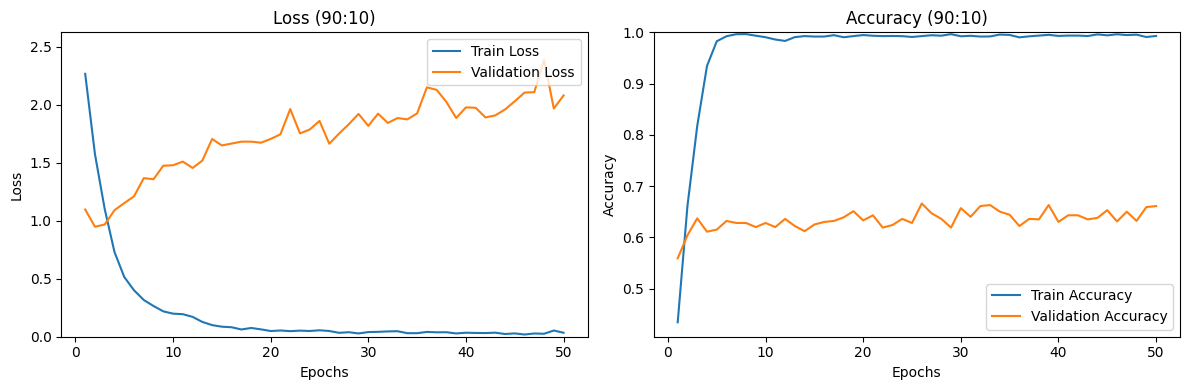

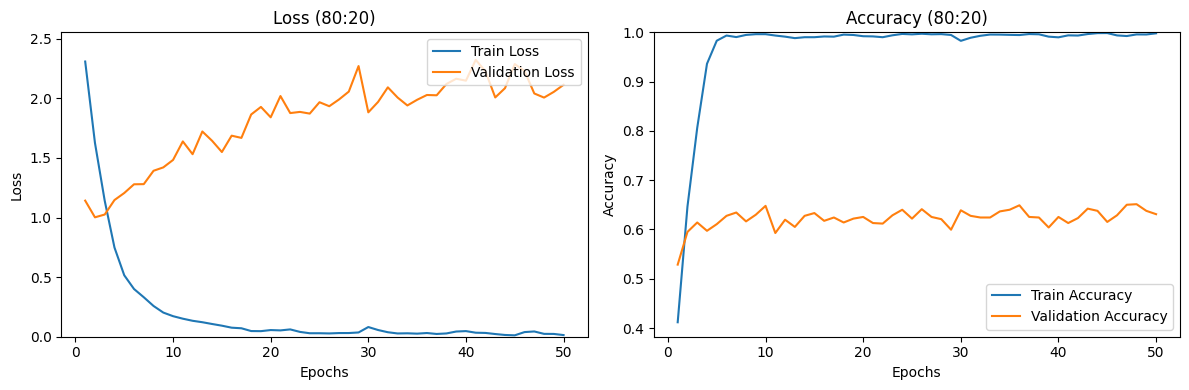

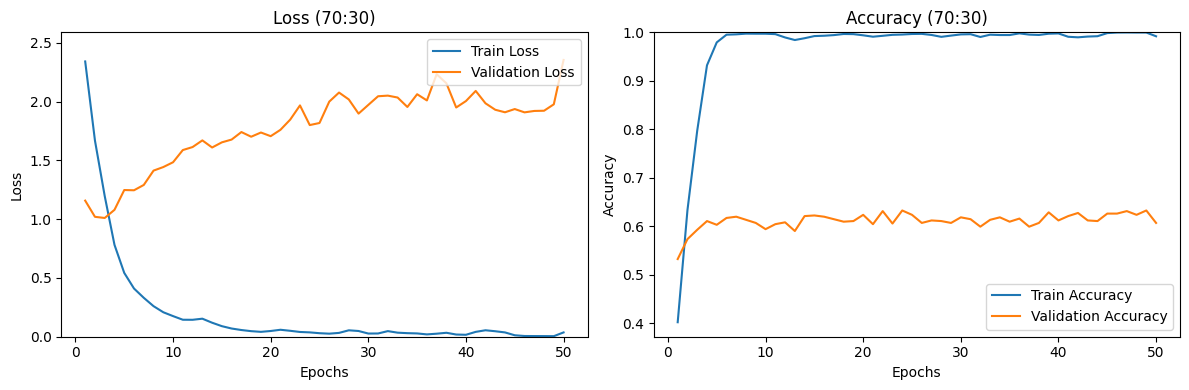

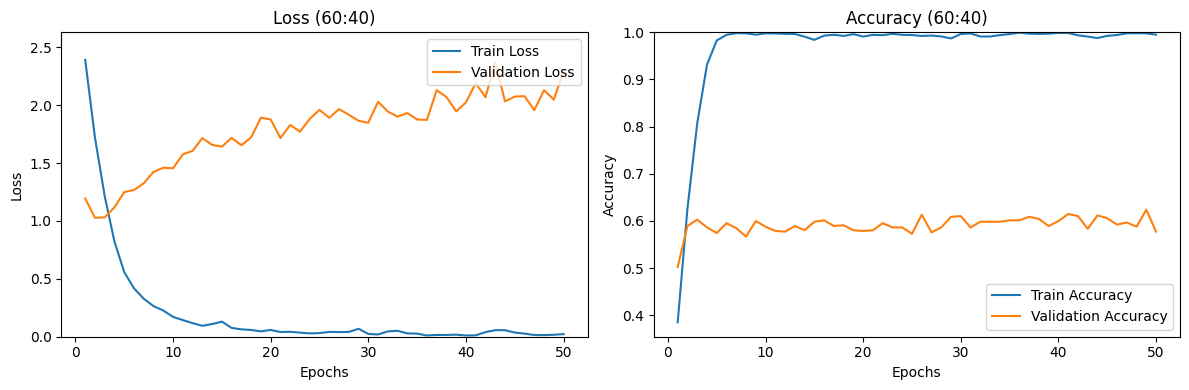

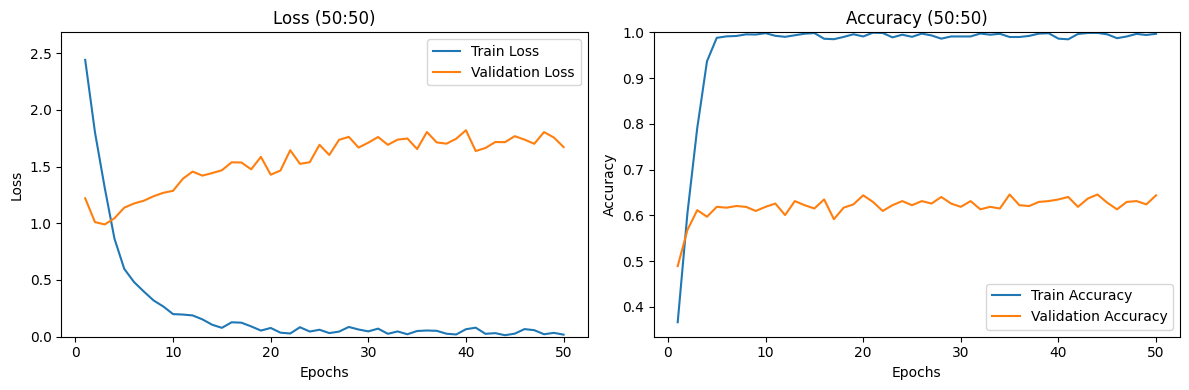

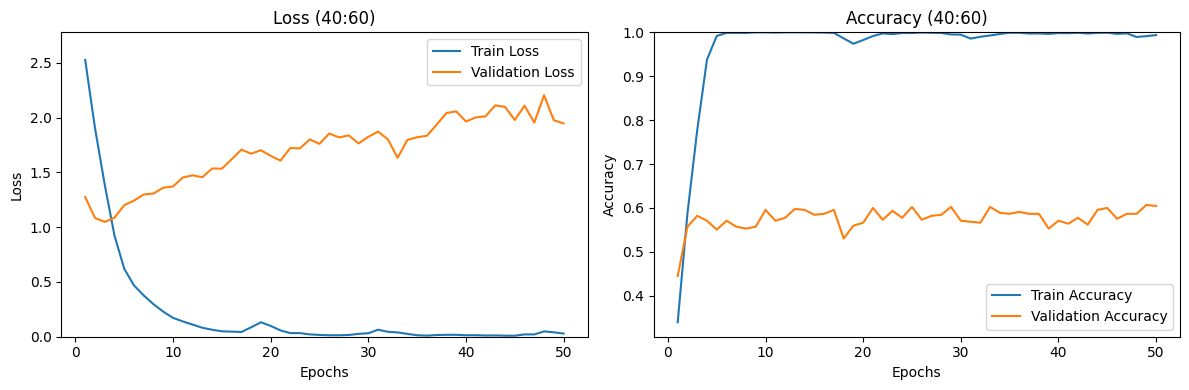

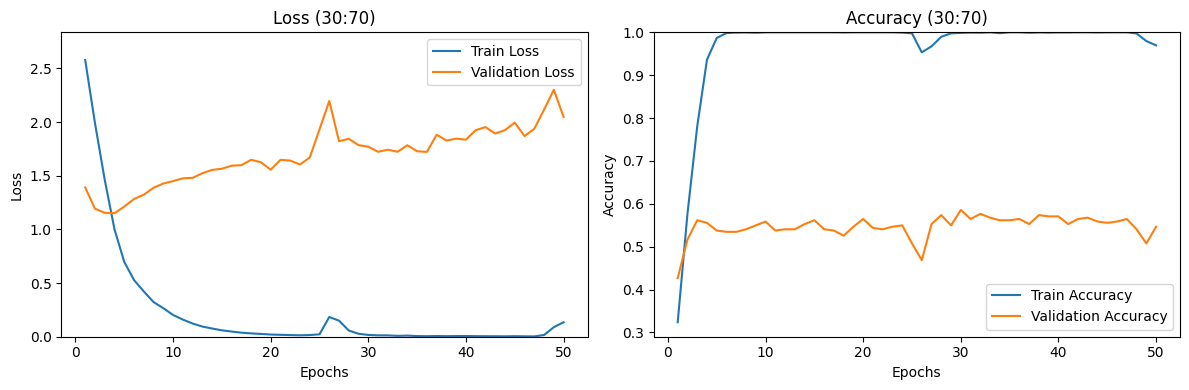

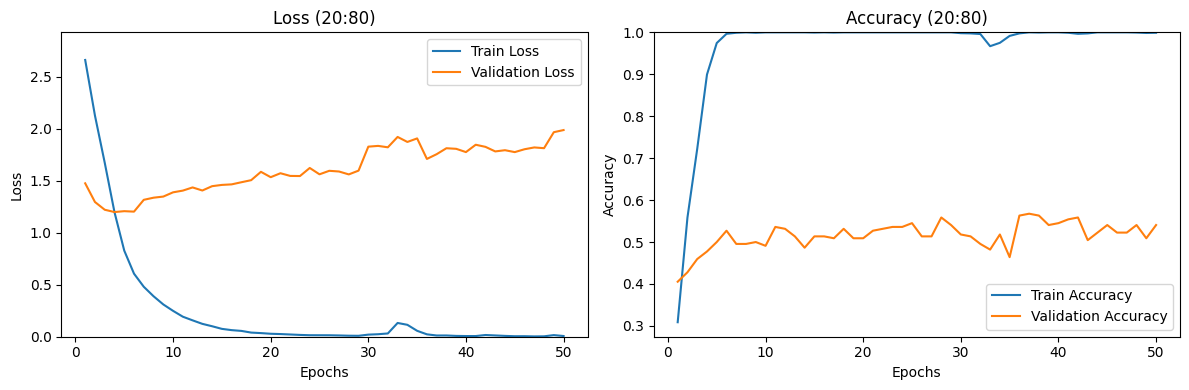

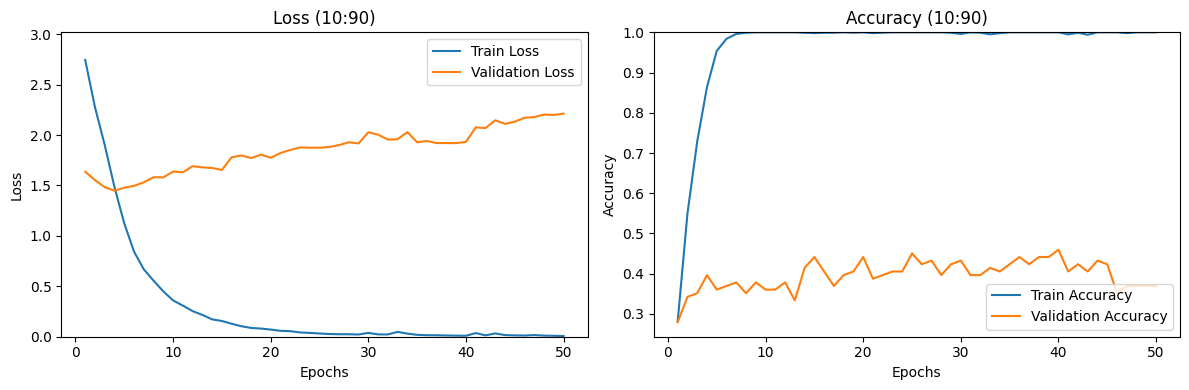

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

BASE_DIR = "/kaggle/working/task2_googlenet"  # <-- updated

for (tr, te) in RATIOS:
    save_path_checkpoints = os.path.join(BASE_DIR, f"{tr}_{te}")
    hist_xlsx = os.path.join(save_path_checkpoints, "training_data.xlsx")
    if not os.path.exists(hist_xlsx):
        print(f"[{tr}:{te}] history file missing at {hist_xlsx}")
        continue

    history = pd.read_excel(hist_xlsx)

    plt.figure(figsize=(12, 4))

    # ----- Loss -----
    plt.subplot(1, 2, 1)
    plt.plot(history['Epoch'], history['Train Loss'], label='Train Loss')
    plt.plot(history['Epoch'], history['Validation Loss'], label='Validation Loss')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.title(f'Loss ({tr}:{te})'); plt.legend(loc='upper right')
    # safer y-lims
    all_loss = pd.concat([history['Train Loss'], history['Validation Loss']])
    lo, hi = float(all_loss.min()), float(all_loss.max())
    pad = 0.1 * (hi - lo if hi > lo else 1.0)
    plt.ylim(max(0.0, lo - pad), hi + pad)

    # ----- Accuracy -----
    plt.subplot(1, 2, 2)
    plt.plot(history['Epoch'], history['Train Accuracy'], label='Train Accuracy')
    plt.plot(history['Epoch'], history['Validation Accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.title(f'Accuracy ({tr}:{te})'); plt.legend(loc='lower right')
    # clamp to [0,1]
    all_acc = pd.concat([history['Train Accuracy'], history['Validation Accuracy']]).clip(lower=0, upper=1)
    lo, hi = float(all_acc.min()), float(all_acc.max())
    pad = 0.05 * (hi - lo if hi > lo else 1.0)
    plt.ylim(max(0.0, lo - pad), min(1.0, hi + pad))

    plt.tight_layout()
    plot_path = os.path.join(save_path_checkpoints, "curves.png")
    plt.savefig(plot_path)
    plt.show()



**Defines evaluate_model() to test a trained model on any dataset.It computes average loss and overall accuracy, and optionally returns predictions, true labels, and softmax probabilities.The model runs in evaluation mode (torch.no_grad()), ensuring no gradient updates during inference.**


In [20]:
import torch
import numpy as np

def evaluate_model(model, criterion, dataloader, return_preds=False):
    """
    Evaluate model on given dataloader.

    Args:
        model: PyTorch model
        criterion: loss function
        dataloader: DataLoader for evaluation
        return_preds: bool, if True returns all predictions and labels (and probs)

    Returns:
        loss: average loss
        accuracy: overall accuracy
        (optional) all_preds, all_labels, all_probs (softmax)
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            probs = torch.softmax(outputs, dim=1)

            _, predicted = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if return_preds:
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

    loss = running_loss / total 
    accuracy = correct / total

    if return_preds:
        return loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)
    else:
        return loss, accuracy


**This block reloads the best saved model for each (train:test) ratio and evaluates it on the validation set.It restores model weights, optimizer state, and epoch info from model.pt, rebuilds DataLoaders, and reports validation loss and accuracy for the saved best epoch.**


In [21]:
import os
import torch
from torchvision import models
from torch import nn

BASE_DIR = "/kaggle/working/task2_googlenet"
num_classes = len(df['label'].unique())
criterion = nn.CrossEntropyLoss()

for (tr, te) in RATIOS:
    print(f"\n[Validation Eval] Ratio {tr}:{te}")
    save_path_checkpoints = os.path.join(BASE_DIR, f"{tr}_{te}")
    best_checkpoint_path = os.path.join(save_path_checkpoints, "model.pt")
    if not os.path.exists(best_checkpoint_path):
        print(f"Missing checkpoint: {best_checkpoint_path}")
        continue

    # Rebuild GoogLeNet exactly like training
    model = models.googlenet(weights=None, aux_logits=True)   # we're loading our own checkpoint
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    if getattr(model, "aux1", None) is not None:
        model.aux1.fc2 = nn.Linear(model.aux1.fc2.in_features, num_classes)
    if getattr(model, "aux2", None) is not None:
        model.aux2.fc2 = nn.Linear(model.aux2.fc2.in_features, num_classes)
    model = model.to(device)  # move AFTER replacing layers

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    checkpoint = torch.load(best_checkpoint_path, map_location=device)
    best_epoch = checkpoint["epoch"]
    model.load_state_dict(checkpoint["model_weight"])
    try:
        optimizer.load_state_dict(checkpoint["optimizer_state"])
    except Exception:
        pass

    split = SPLITS[(tr, te)]
    _, dataloader_valid_dataset, _ = data_transform(split["train_df"], split["valid_df"], split["test_df"])

    # evaluate_model must extract main logits (as in the earlier fixed version)
    best_val_loss, best_val_accuracy = evaluate_model(model, criterion, dataloader_valid_dataset)
    print(f"Best model (from epoch {best_epoch}) - Validation Loss: {best_val_loss:.3f}, Validation Accuracy: {best_val_accuracy:.3f}")



[Validation Eval] Ratio 90:10


/usr/local/lib/python3.11/dist-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Best model (from epoch 26) - Validation Loss: 5.630, Validation Accuracy: 0.288

[Validation Eval] Ratio 80:20
Best model (from epoch 48) - Validation Loss: 3.992, Validation Accuracy: 0.346

[Validation Eval] Ratio 70:30
Best model (from epoch 24) - Validation Loss: 4.884, Validation Accuracy: 0.297

[Validation Eval] Ratio 60:40
Best model (from epoch 49) - Validation Loss: 3.622, Validation Accuracy: 0.385

[Validation Eval] Ratio 50:50
Best model (from epoch 35) - Validation Loss: 3.080, Validation Accuracy: 0.354

[Validation Eval] Ratio 40:60
Best model (from epoch 49) - Validation Loss: 3.357, Validation Accuracy: 0.404

[Validation Eval] Ratio 30:70
Best model (from epoch 30) - Validation Loss: 4.023, Validation Accuracy: 0.264

[Validation Eval] Ratio 20:80
Best model (from epoch 37) - Validation Loss: 3.167, Validation Accuracy: 0.293

[Validation Eval] Ratio 10:90
Best model (from epoch 40) - Validation Loss: 2.960, Validation Accuracy: 0.279



**Evaluates the best checkpoint for each (train:test) ratio on the test set and reports:Overall test loss, accuracy, and inference time (total + per image).Per-class accuracy, full classification report, and Macro ROC–AUC (OvR).Saves a normalized confusion matrix (cm_norm_*.png) and per-class ROC curves (roc_*.png).Lists the top confused class pairs (True → Pred) to highlight common mistakes.**



[TEST] Ratio 90:10
Test Loss: 5.652, Test Accuracy: 0.284
Total Test Time: 7.63 seconds for 1111 images
Average Inference Time per Image: 0.006865 s (~6.86 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.883817
1            Hazardous  0.187500
2             Moderate  0.219917
3            Unhealthy  0.020747
4  Unhealthy_Sensitive  0.066946
5       Very_Unhealthy  0.188119

Classification Report:

                     precision    recall  f1-score   support

               Good     0.2720    0.8838    0.4160       241
          Hazardous     0.6429    0.1875    0.2903        48
           Moderate     0.2218    0.2199    0.2208       241
          Unhealthy     1.0000    0.0207    0.0407       241
Unhealthy_Sensitive     0.3333    0.0669    0.1115       239
     Very_Unhealthy     0.8636    0.1881    0.3089       101

           accuracy                         0.2835      1111
          macro avg     0.5556    0.2612    0.2314      1111
     

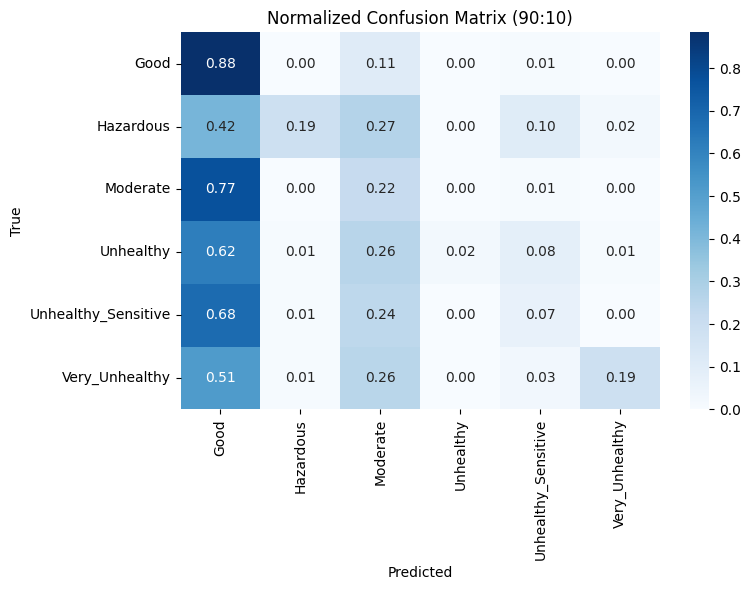

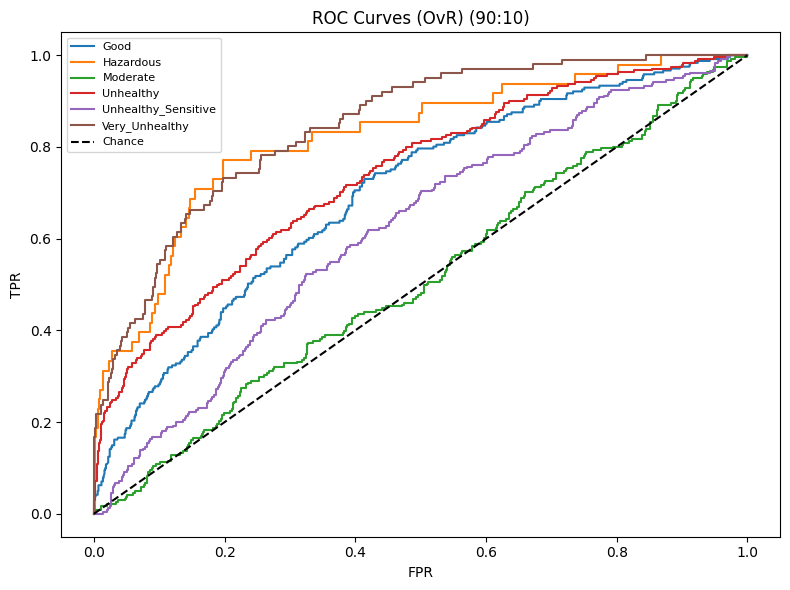


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.77
  Unhealthy_Sensitive → Good               : 0.68
           Unhealthy → Good               : 0.62
      Very_Unhealthy → Good               : 0.51
           Hazardous → Good               : 0.42

[TEST] Ratio 80:20


/usr/local/lib/python3.11/dist-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Test Loss: 3.976, Test Accuracy: 0.361
Total Test Time: 15.40 seconds for 2221 images
Average Inference Time per Image: 0.006935 s (~6.93 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.678423
1            Hazardous  0.156250
2             Moderate  0.375519
3            Unhealthy  0.066528
4  Unhealthy_Sensitive  0.379958
5       Very_Unhealthy  0.318408

Classification Report:

                     precision    recall  f1-score   support

               Good     0.3621    0.6784    0.4722       482
          Hazardous     0.4054    0.1562    0.2256        96
           Moderate     0.2642    0.3755    0.3102       482
          Unhealthy     1.0000    0.0665    0.1248       481
Unhealthy_Sensitive     0.3957    0.3800    0.3876       479
     Very_Unhealthy     0.6154    0.3184    0.4197       201

           accuracy                         0.3606      2221
          macro avg     0.5071    0.3292    0.3233      2221
       weighted avg     

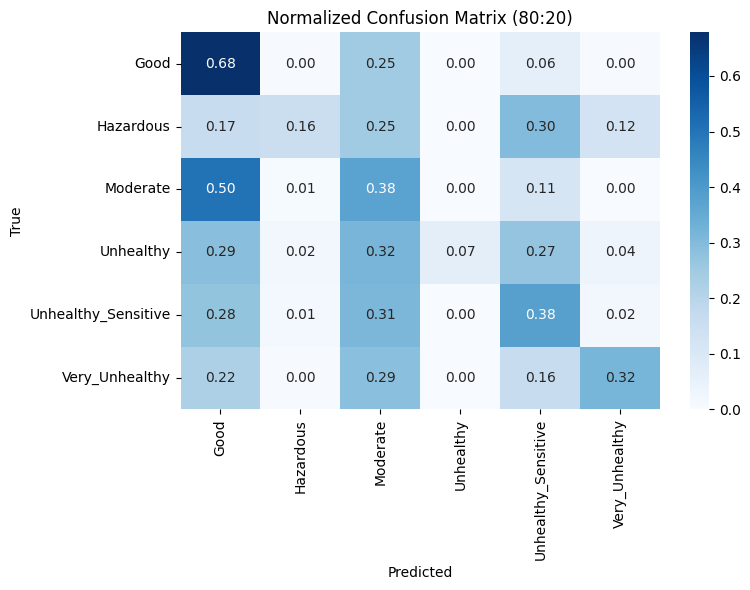

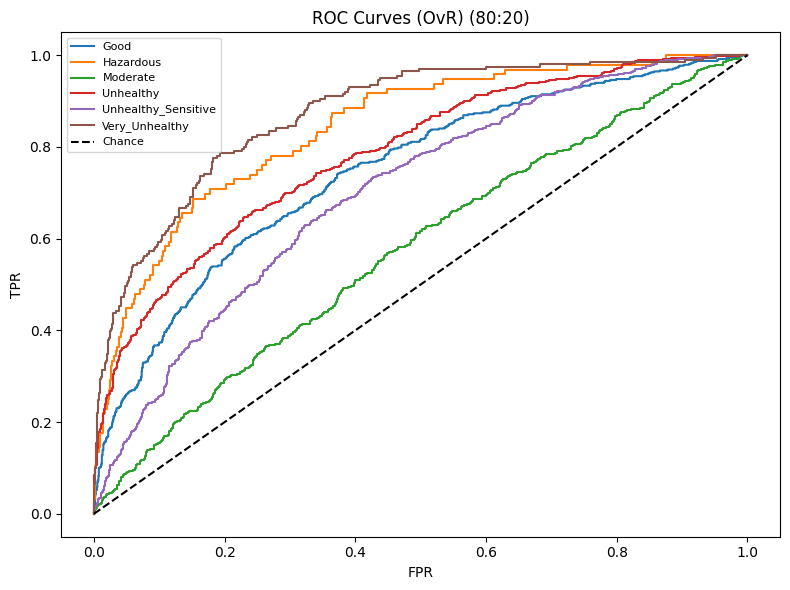


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.50
           Unhealthy → Moderate           : 0.32
  Unhealthy_Sensitive → Moderate           : 0.31
           Hazardous → Unhealthy_Sensitive : 0.30
           Unhealthy → Good               : 0.29

[TEST] Ratio 70:30


/usr/local/lib/python3.11/dist-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Test Loss: 4.959, Test Accuracy: 0.281
Total Test Time: 23.32 seconds for 3331 images
Average Inference Time per Image: 0.007001 s (~7.00 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.901798
1            Hazardous  0.104167
2             Moderate  0.142659
3            Unhealthy  0.026316
4  Unhealthy_Sensitive  0.094708
5       Very_Unhealthy  0.264901

Classification Report:

                     precision    recall  f1-score   support

               Good     0.2503    0.9018    0.3918       723
          Hazardous     0.4054    0.1042    0.1657       144
           Moderate     0.2614    0.1427    0.1846       722
          Unhealthy     0.9048    0.0263    0.0511       722
Unhealthy_Sensitive     0.5152    0.0947    0.1600       718
     Very_Unhealthy     0.5634    0.2649    0.3604       302

           accuracy                         0.2813      3331
          macro avg     0.4834    0.2558    0.2189      3331
       weighted avg     

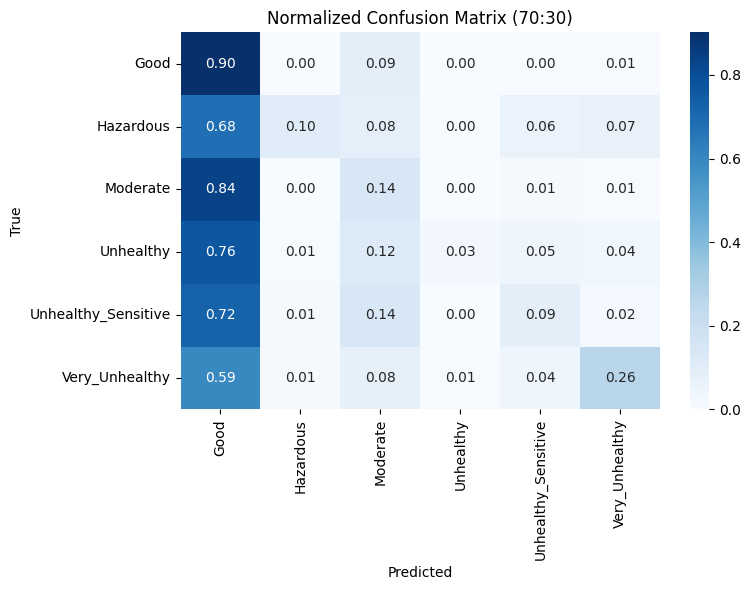

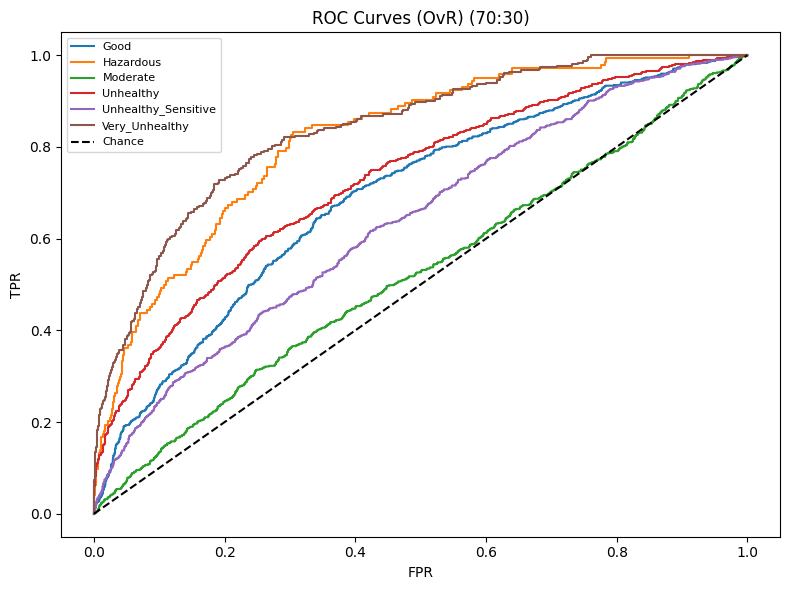


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.84
           Unhealthy → Good               : 0.76
  Unhealthy_Sensitive → Good               : 0.72
           Hazardous → Good               : 0.68
      Very_Unhealthy → Good               : 0.59

[TEST] Ratio 60:40


/usr/local/lib/python3.11/dist-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Test Loss: 3.834, Test Accuracy: 0.358
Total Test Time: 31.20 seconds for 4442 images
Average Inference Time per Image: 0.007023 s (~7.02 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.600208
1            Hazardous  0.155440
2             Moderate  0.375909
3            Unhealthy  0.098650
4  Unhealthy_Sensitive  0.403344
5       Very_Unhealthy  0.342432

Classification Report:

                     precision    recall  f1-score   support

               Good     0.3280    0.6002    0.4242       963
          Hazardous     0.4225    0.1554    0.2273       193
           Moderate     0.2992    0.3759    0.3332       963
          Unhealthy     0.8482    0.0987    0.1767       963
Unhealthy_Sensitive     0.3635    0.4033    0.3824       957
     Very_Unhealthy     0.6133    0.3424    0.4395       403

           accuracy                         0.3577      4442
          macro avg     0.4791    0.3293    0.3305      4442
       weighted avg     

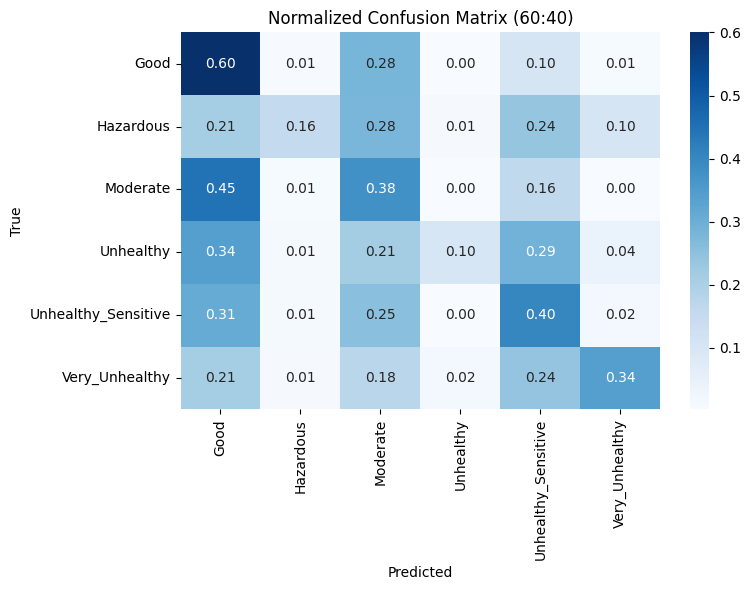

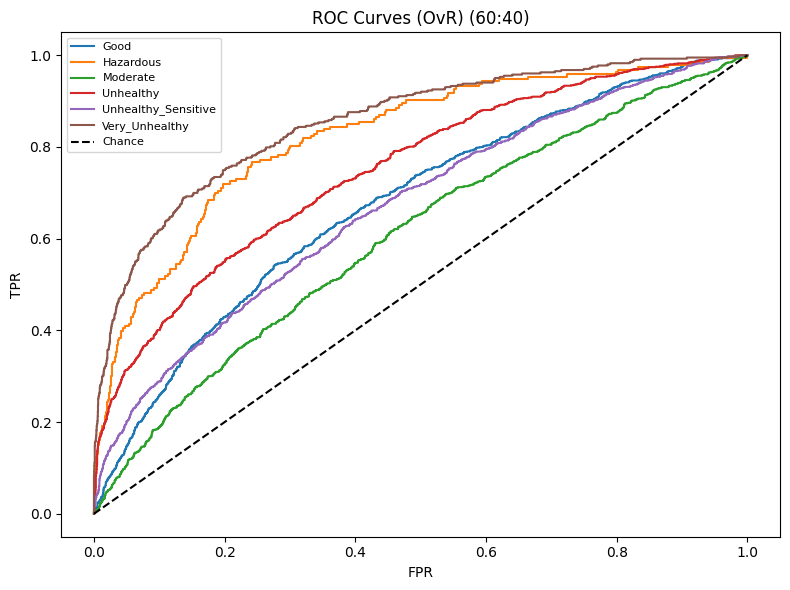


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.45
           Unhealthy → Good               : 0.34
  Unhealthy_Sensitive → Good               : 0.31
           Unhealthy → Unhealthy_Sensitive : 0.29
                Good → Moderate           : 0.28

[TEST] Ratio 50:50


/usr/local/lib/python3.11/dist-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Test Loss: 3.348, Test Accuracy: 0.349
Total Test Time: 40.10 seconds for 5552 images
Average Inference Time per Image: 0.007223 s (~7.22 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.681894
1            Hazardous  0.312500
2             Moderate  0.426910
3            Unhealthy  0.157807
4  Unhealthy_Sensitive  0.187135
5       Very_Unhealthy  0.220676

Classification Report:

                     precision    recall  f1-score   support

               Good     0.3182    0.6819    0.4339      1204
          Hazardous     0.6098    0.3125    0.4132       240
           Moderate     0.2603    0.4269    0.3234      1204
          Unhealthy     0.8297    0.1578    0.2652      1204
Unhealthy_Sensitive     0.4444    0.1871    0.2634      1197
     Very_Unhealthy     0.7872    0.2207    0.3447       503

           accuracy                         0.3485      5552
          macro avg     0.5416    0.3312    0.3406      5552
       weighted avg     

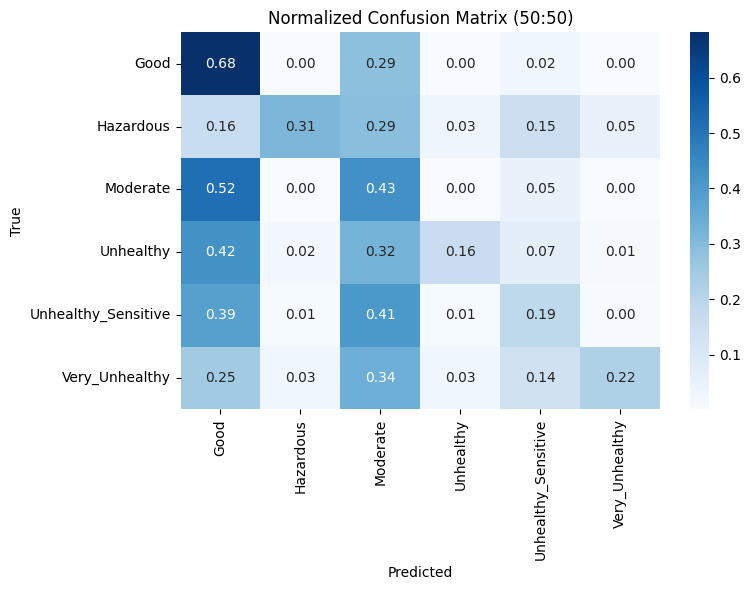

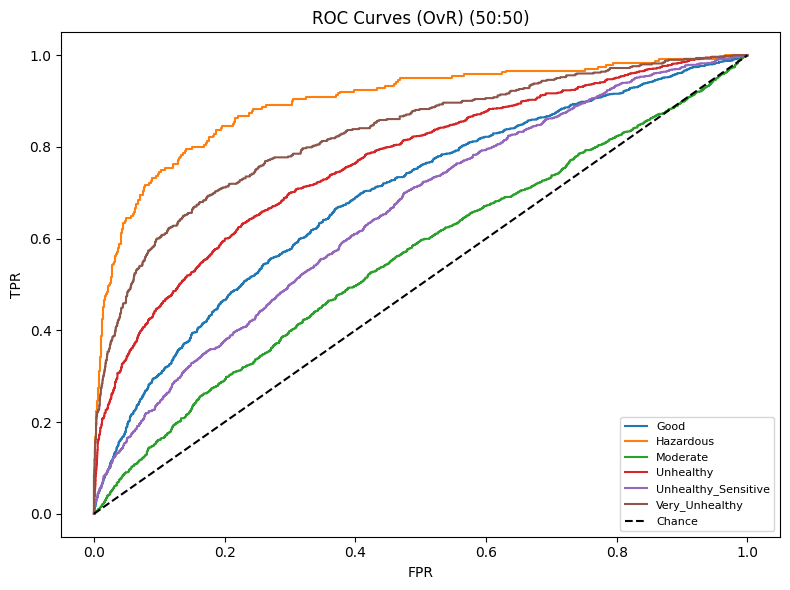


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.52
           Unhealthy → Good               : 0.42
  Unhealthy_Sensitive → Moderate           : 0.41
  Unhealthy_Sensitive → Good               : 0.39
      Very_Unhealthy → Moderate           : 0.34

[TEST] Ratio 40:60


/usr/local/lib/python3.11/dist-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Test Loss: 3.420, Test Accuracy: 0.380
Total Test Time: 45.76 seconds for 6662 images
Average Inference Time per Image: 0.006869 s (~6.87 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.442215
1            Hazardous  0.058824
2             Moderate  0.409972
3            Unhealthy  0.176593
4  Unhealthy_Sensitive  0.597493
5       Very_Unhealthy  0.281457

Classification Report:

                     precision    recall  f1-score   support

               Good     0.4136    0.4422    0.4274      1445
          Hazardous     0.8947    0.0588    0.1104       289
           Moderate     0.3004    0.4100    0.3467      1444
          Unhealthy     0.6967    0.1766    0.2818      1444
Unhealthy_Sensitive     0.3401    0.5975    0.4334      1436
     Very_Unhealthy     0.7143    0.2815    0.4038       604

           accuracy                         0.3799      6662
          macro avg     0.5600    0.3278    0.3339      6662
       weighted avg     

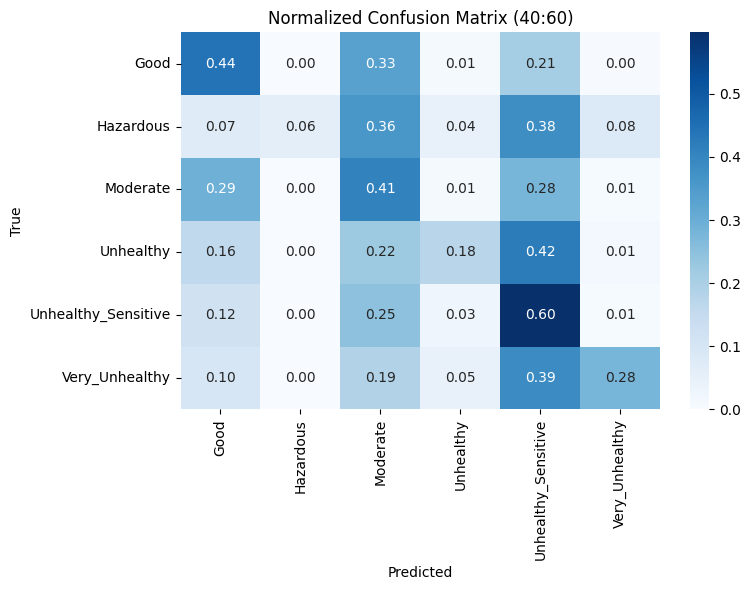

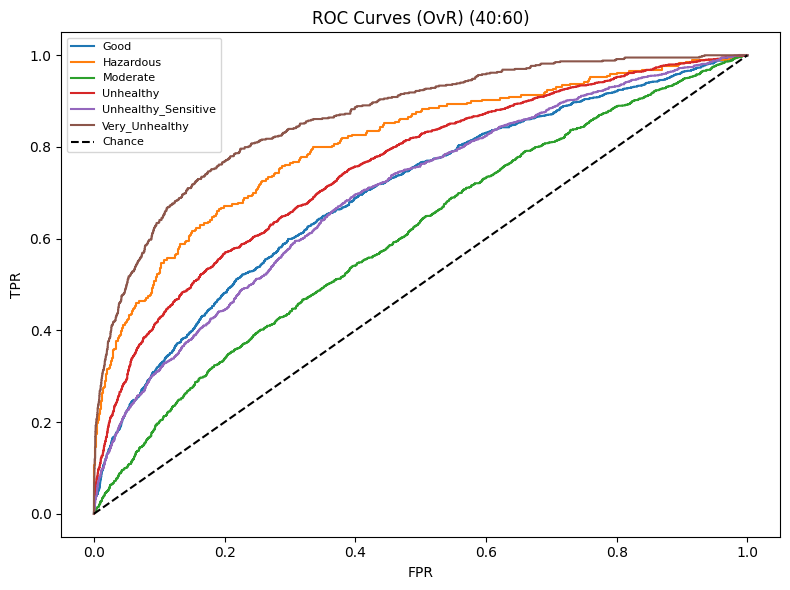


Top Confused Pairs (True → Pred, rate):
           Unhealthy → Unhealthy_Sensitive : 0.42
      Very_Unhealthy → Unhealthy_Sensitive : 0.39
           Hazardous → Unhealthy_Sensitive : 0.38
           Hazardous → Moderate           : 0.36
                Good → Moderate           : 0.33

[TEST] Ratio 30:70


/usr/local/lib/python3.11/dist-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Test Loss: 3.993, Test Accuracy: 0.290
Total Test Time: 56.54 seconds for 7773 images
Average Inference Time per Image: 0.007274 s (~7.27 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.888493
1            Hazardous  0.091988
2             Moderate  0.154303
3            Unhealthy  0.022552
4  Unhealthy_Sensitive  0.186269
5       Very_Unhealthy  0.160284

Classification Report:

                     precision    recall  f1-score   support

               Good     0.2589    0.8885    0.4010      1686
          Hazardous     0.7209    0.0920    0.1632       337
           Moderate     0.2582    0.1543    0.1932      1685
          Unhealthy     0.7308    0.0226    0.0438      1685
Unhealthy_Sensitive     0.4205    0.1863    0.2582      1675
     Very_Unhealthy     0.7902    0.1603    0.2665       705

           accuracy                         0.2897      7773
          macro avg     0.5299    0.2506    0.2210      7773
       weighted avg     

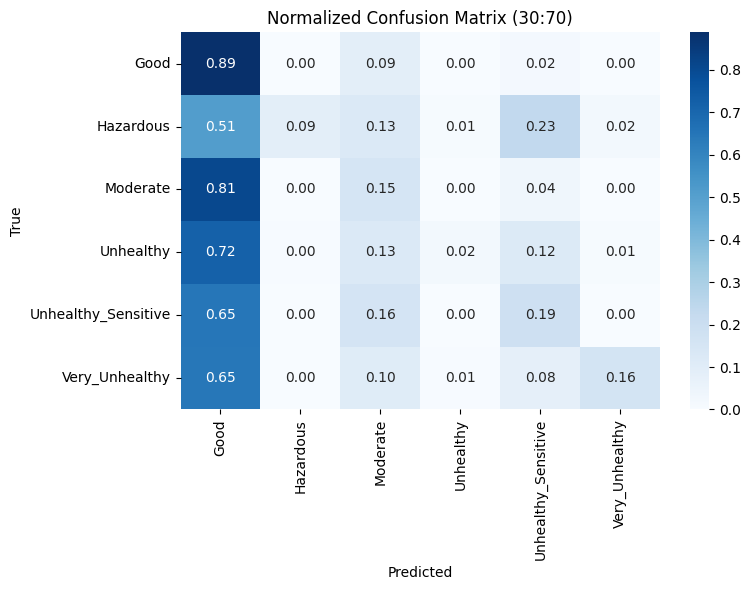

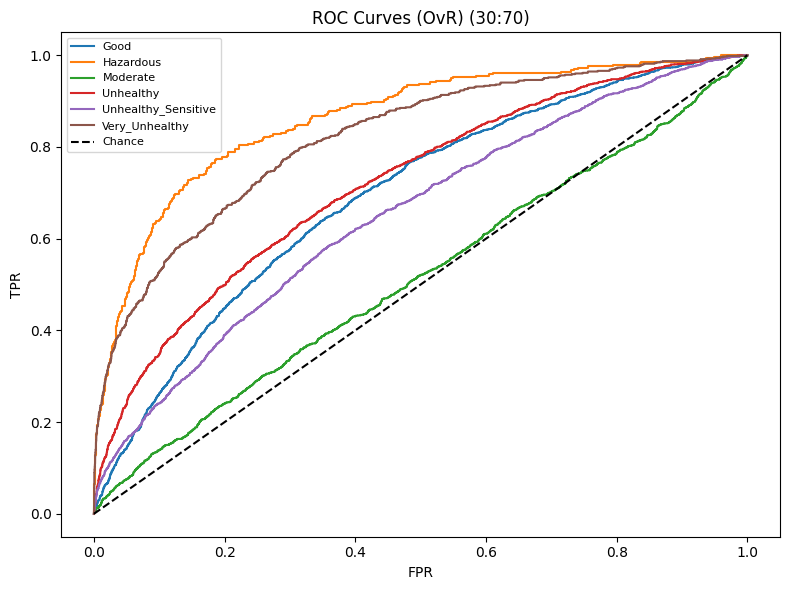


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.81
           Unhealthy → Good               : 0.72
  Unhealthy_Sensitive → Good               : 0.65
      Very_Unhealthy → Good               : 0.65
           Hazardous → Good               : 0.51

[TEST] Ratio 20:80


/usr/local/lib/python3.11/dist-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Test Loss: 3.168, Test Accuracy: 0.301
Total Test Time: 62.39 seconds for 8883 images
Average Inference Time per Image: 0.007023 s (~7.02 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.628245
1            Hazardous  0.085714
2             Moderate  0.377466
3            Unhealthy  0.060228
4  Unhealthy_Sensitive  0.179728
5       Very_Unhealthy  0.302730

Classification Report:

                     precision    recall  f1-score   support

               Good     0.2709    0.6282    0.3786      1926
          Hazardous     0.9706    0.0857    0.1575       385
           Moderate     0.2498    0.3775    0.3007      1926
          Unhealthy     0.8657    0.0602    0.1126      1926
Unhealthy_Sensitive     0.3835    0.1797    0.2448      1914
     Very_Unhealthy     0.5520    0.3027    0.3910       806

           accuracy                         0.3010      8883
          macro avg     0.5488    0.2724    0.2642      8883
       weighted avg     

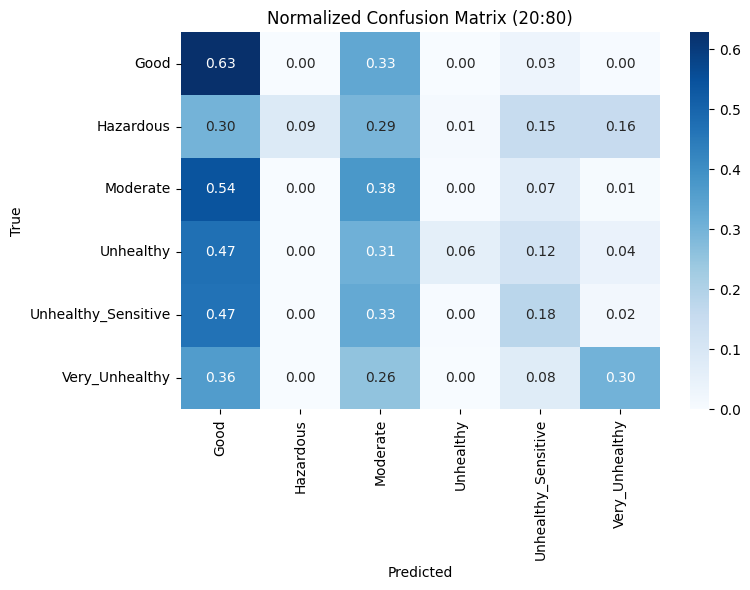

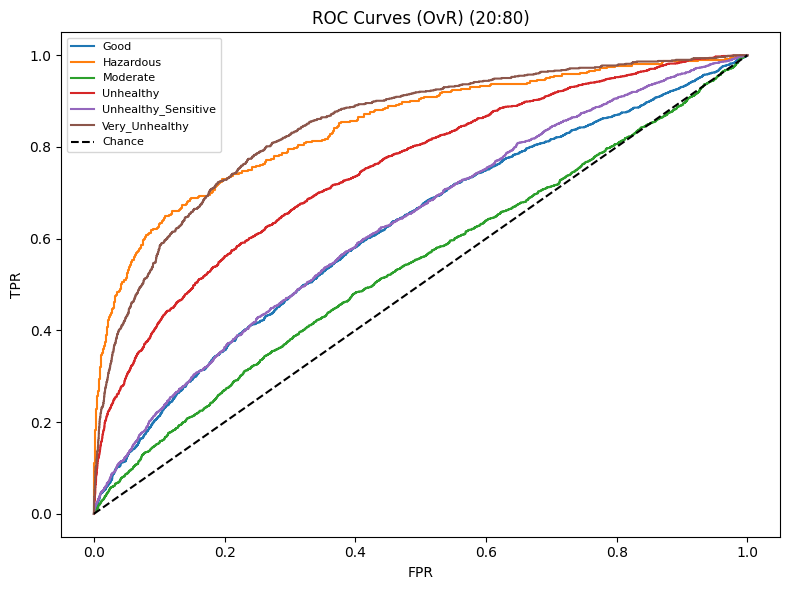


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.54
           Unhealthy → Good               : 0.47
  Unhealthy_Sensitive → Good               : 0.47
      Very_Unhealthy → Good               : 0.36
                Good → Moderate           : 0.33

[TEST] Ratio 10:90


/usr/local/lib/python3.11/dist-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Test Loss: 2.923, Test Accuracy: 0.277
Total Test Time: 71.88 seconds for 9993 images
Average Inference Time per Image: 0.007194 s (~7.19 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.463775
1            Hazardous  0.099307
2             Moderate  0.577757
3            Unhealthy  0.020314
4  Unhealthy_Sensitive  0.159239
5       Very_Unhealthy  0.089404

Classification Report:

                     precision    recall  f1-score   support

               Good     0.3347    0.4638    0.3888      2167
          Hazardous     0.8958    0.0993    0.1788       433
           Moderate     0.2264    0.5778    0.3253      2167
          Unhealthy     0.6769    0.0203    0.0394      2166
Unhealthy_Sensitive     0.2733    0.1592    0.2012      2154
     Very_Unhealthy     0.8804    0.0894    0.1623       906

           accuracy                         0.2770      9993
          macro avg     0.5479    0.2350    0.2160      9993
       weighted avg     

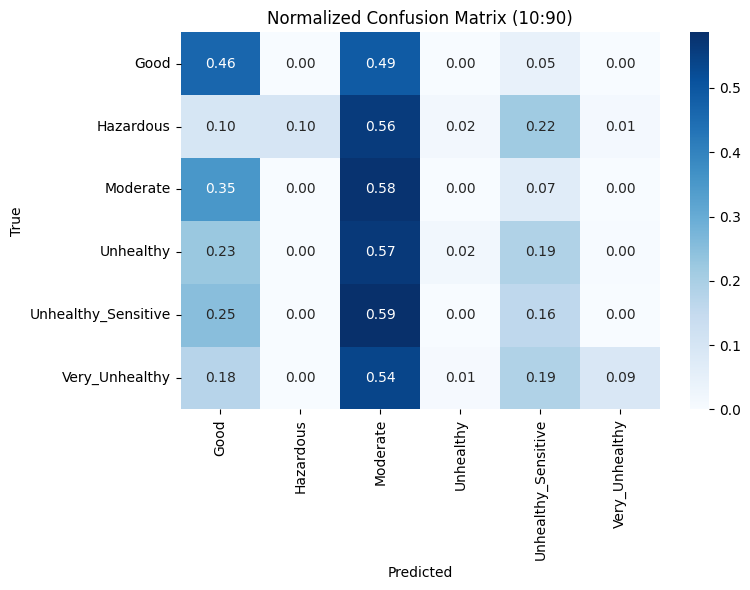

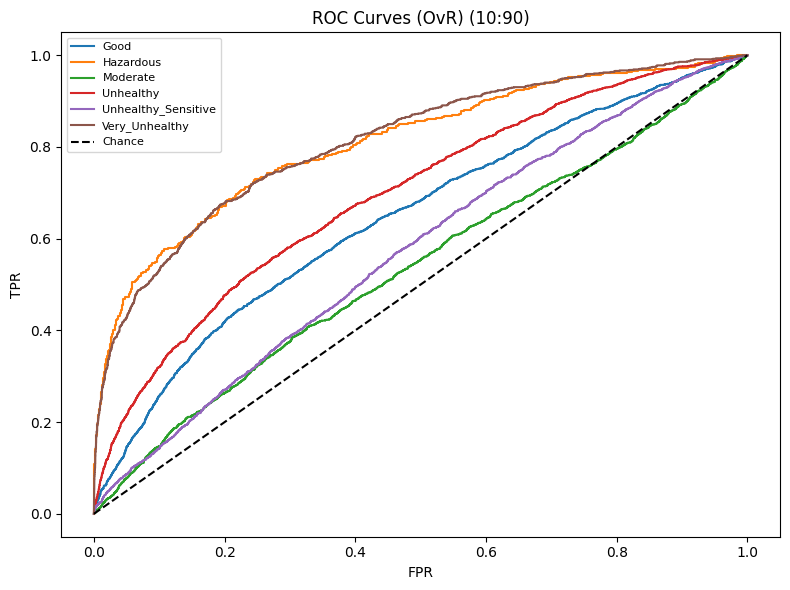


Top Confused Pairs (True → Pred, rate):
  Unhealthy_Sensitive → Moderate           : 0.59
           Unhealthy → Moderate           : 0.57
           Hazardous → Moderate           : 0.56
      Very_Unhealthy → Moderate           : 0.54
                Good → Moderate           : 0.49


In [22]:
import time
import os
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torchvision import models

CLASS_NAMES = sorted(df['label'].unique())
CLASS_TO_ID = {c:i for i, c in enumerate(CLASS_NAMES)}
BASE_DIR = "/kaggle/working/task2_googlenet"  # <-- match GoogLeNet run

criterion = nn.CrossEntropyLoss()

for (tr, te) in RATIOS:
    print(f"\n[TEST] Ratio {tr}:{te}")
    save_path_checkpoints = os.path.join(BASE_DIR, f"{tr}_{te}")
    best_checkpoint_path = os.path.join(save_path_checkpoints, "model.pt")
    if not os.path.exists(best_checkpoint_path):
        print(f"Missing checkpoint: {best_checkpoint_path}")
        continue

    # Rebuild GoogLeNet like during training
    num_classes = len(CLASS_NAMES)
    model = models.googlenet(weights=None, aux_logits=True)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    if getattr(model, "aux1", None) is not None:
        model.aux1.fc2 = nn.Linear(model.aux1.fc2.in_features, num_classes)
    if getattr(model, "aux2", None) is not None:
        model.aux2.fc2 = nn.Linear(model.aux2.fc2.in_features, num_classes)
    model = model.to(device)  # move AFTER replacing layers

    # Load checkpoint weights
    checkpoint = torch.load(best_checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_weight"])

    # Dataloaders for this ratio
    split = SPLITS[(tr, te)]
    _, _, dataloader_test_dataset = data_transform(split["train_df"], split["valid_df"], split["test_df"])

    # Evaluate (evaluate_model should extract main logits if aux present)
    start_time = time.time()
    test_loss, test_accuracy, all_preds, all_labels, all_probs = evaluate_model(
        model, criterion, dataloader_test_dataset, return_preds=True
    )
    end_time = time.time()
    test_time = end_time - start_time

    n_test_images = len(split["test_df"])
    avg_inf_per_image_sec = test_time / n_test_images if n_test_images > 0 else float('nan')
    avg_inf_per_image_ms = avg_inf_per_image_sec * 1000.0

    print(f"Test Loss: {test_loss:.3f}, Test Accuracy: {test_accuracy:.3f}")
    print(f"Total Test Time: {test_time:.2f} seconds for {n_test_images} images")
    print(f"Average Inference Time per Image: {avg_inf_per_image_sec:.6f} s (~{avg_inf_per_image_ms:.2f} ms/image)")

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds, labels=np.arange(num_classes))
    with np.errstate(divide='ignore', invalid='ignore'):
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_norm[np.isnan(cm_norm)] = 0.0  # handle any empty-class edge case

    # Per-class accuracy (robust)
    with np.errstate(divide='ignore', invalid='ignore'):
        per_class_acc = np.divide(cm.diagonal(), cm.sum(axis=1), out=np.zeros_like(cm.diagonal(), dtype=float), where=cm.sum(axis=1)!=0)
    per_class_acc_df = pd.DataFrame({'Class': CLASS_NAMES, 'Accuracy': per_class_acc})
    print("\nPer-Class Accuracy:")
    print(per_class_acc_df)

    # Classification report
    report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4)
    print("\nClassification Report:\n")
    print(report)

    # ROC–AUC (OvR)
    try:
        y_true_bin = label_binarize(all_labels, classes=np.arange(num_classes))
        macro_auc = roc_auc_score(y_true_bin, all_probs, average='macro', multi_class='ovr')
    except Exception:
        macro_auc = np.nan
    print(f"Macro ROC–AUC (OvR): {macro_auc if not np.isnan(macro_auc) else 'NA'}")

    # Plot CM
    plt.figure(figsize=(8,6))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Normalized Confusion Matrix ({tr}:{te})')
    cm_path = os.path.join(save_path_checkpoints, f'cm_norm_{tr}-{te}.png')
    plt.tight_layout()
    plt.savefig(cm_path)
    plt.show()

    # ROC curves (OvR)
    try:
        plt.figure(figsize=(8,6))
        for i, cname in enumerate(CLASS_NAMES):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
            plt.plot(fpr, tpr, label=cname)
        plt.plot([0,1],[0,1],'k--',label='Chance')
        plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(f'ROC Curves (OvR) ({tr}:{te})'); plt.legend(fontsize=8)
        roc_path = os.path.join(save_path_checkpoints, f'roc_{tr}-{te}.png')
        plt.tight_layout(); plt.savefig(roc_path); plt.show()
    except Exception:
        pass

    # Top confused pairs
    cm_norm_off = cm_norm.copy()
    np.fill_diagonal(cm_norm_off, 0.0)
    confused = [(CLASS_NAMES[i], CLASS_NAMES[j], cm_norm_off[i, j])
                for i in range(num_classes) for j in range(num_classes) if i != j]
    confused.sort(key=lambda x: x[2], reverse=True)
    top_k = [c for c in confused if np.isfinite(c[2]) and c[2] > 0][:5]
    if top_k:
        print("\nTop Confused Pairs (True → Pred, rate):")
        for (t, p, r) in top_k:
            print(f"  {t:>18s} → {p:<18s} : {r:.2f}")
    else:
        print("\nNo significant confused pairs detected.")
